In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')


df = pd.read_parquet('../data/processed/internacoes_psiquiatricas.parquet')

print(f"Registros: {len(df):,}")
print(f"Período: {df['DT_INTER'].min().date()} a {df['DT_INTER'].max().date()}")

Registros: 460,446
Período: 2017-01-01 a 2023-12-31


In [7]:
df = df[df['ANO'].between(2017, 2023)].copy()

def classificar_periodo(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2021:
        return 'Pandemia'
    else:
        return 'Pós-pandemia'

df['PERIODO'] = df['ANO'].apply(classificar_periodo)

print(df['PERIODO'].value_counts())
print(f"\nTotal de registros: {len(df):,}")

PERIODO
Pré-pandemia    170157
Pós-pandemia    151704
Pandemia        138585
Name: count, dtype: int64

Total de registros: 460,446


In [8]:
print(df[df['PERIODO'] == 'Pré-pandemia']['ANO'].value_counts())

ANO
2017    83395
2018    72757
2019    14005
Name: count, dtype: int64


In [10]:
import glob

arquivos_parquet = glob.glob('../data/raw/*.parquet')
print(f"Total de arquivos: {len(arquivos_parquet)}")

Total de arquivos: 84


In [11]:
dfs = []

for arquivo in arquivos_parquet:
    df_mes = pd.read_parquet(arquivo, engine='pyarrow')
    df_mes = df_mes[df_mes['DIAG_PRINC'].str.startswith('F', na=False)]
    dfs.append(df_mes)
    print(f"{arquivo.split('/')[-1]}: {len(df_mes):,} internações psiquiátricas")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal geral: {len(df_raw):,}")

RDSP2110.parquet: 6,744 internações psiquiátricas
RDSP1707.parquet: 8,075 internações psiquiátricas
RDSP1904.parquet: 8,063 internações psiquiátricas
RDSP1903.parquet: 8,106 internações psiquiátricas
RDSP1804.parquet: 8,216 internações psiquiátricas
RDSP2105.parquet: 5,782 internações psiquiátricas
RDSP2112.parquet: 6,877 internações psiquiátricas
RDSP1806.parquet: 7,837 internações psiquiátricas
RDSP2011.parquet: 6,659 internações psiquiátricas
RDSP2212.parquet: 7,141 internações psiquiátricas
RDSP1811.parquet: 7,591 internações psiquiátricas
RDSP2312.parquet: 7,739 internações psiquiátricas
RDSP1901.parquet: 8,297 internações psiquiátricas
RDSP2307.parquet: 7,515 internações psiquiátricas
RDSP2004.parquet: 6,447 internações psiquiátricas
RDSP2111.parquet: 7,093 internações psiquiátricas
RDSP2308.parquet: 7,889 internações psiquiátricas
RDSP2012.parquet: 6,662 internações psiquiátricas
RDSP1703.parquet: 9,069 internações psiquiátricas
RDSP1709.parquet: 8,532 internações psiquiátricas


In [12]:
colunas = [
    'ANO_CMPT', 'MES_CMPT', 'MUNIC_RES', 'NASC', 'SEXO', 'IDADE',
    'COD_IDADE', 'DIAG_PRINC', 'DIAG_SECUN', 'DT_INTER', 'DT_SAIDA',
    'DIAS_PERM', 'MORTE', 'VAL_TOT', 'RACA_COR', 'CNES', 'COMPLEX', 'FINANC'
]

df = df_raw[colunas].copy()

# tipos numéricos
df['DIAS_PERM'] = pd.to_numeric(df['DIAS_PERM'], errors='coerce')
df['VAL_TOT']   = pd.to_numeric(df['VAL_TOT'], errors='coerce')
df['IDADE']     = pd.to_numeric(df['IDADE'], errors='coerce')

# datas
df['DT_INTER'] = pd.to_datetime(df['DT_INTER'], format='%Y%m%d', errors='coerce')
df['DT_SAIDA'] = pd.to_datetime(df['DT_SAIDA'], format='%Y%m%d', errors='coerce')

# sexo e raça
df['SEXO']     = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})
df['RACA_COR'] = df['RACA_COR'].map({'01': 'Branca', '02': 'Preta', '03': 'Parda', '04': 'Amarela', '05': 'Indígena', '99': 'Ignorado'})

# ano e grupo diagnóstico
df['ANO'] = df['DT_INTER'].dt.year

def categorizar_cid(cid):
    grupos = {
        'F0': 'Transtornos orgânicos',
        'F1': 'Transtornos por uso de substâncias',
        'F2': 'Psicoses (esquizofrenia)',
        'F3': 'Transtornos de humor',
        'F4': 'Transtornos ansiosos',
        'F5': 'Síndromes comportamentais',
        'F6': 'Transtornos de personalidade',
        'F7': 'Deficiência intelectual',
        'F8': 'Transtornos do desenvolvimento',
        'F9': 'Transtornos da infância',
    }
    for prefixo, nome in grupos.items():
        if str(cid).startswith(prefixo):
            return nome
    return 'Outros'

df['GRUPO_DIAG'] = df['DIAG_PRINC'].apply(categorizar_cid)

# filtros
df = df[df['COD_IDADE'] == '4'].copy()
df = df.drop(columns=['COD_IDADE', 'INSTRU'] if 'INSTRU' in df.columns else ['COD_IDADE'])
df = df[df['ANO'].between(2017, 2023)].copy()

# período
def classificar_periodo(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2021:
        return 'Pandemia'
    else:
        return 'Pós-pandemia'

df['PERIODO'] = df['ANO'].apply(classificar_periodo)

print(f"Registros finais: {len(df):,}")
print(df['PERIODO'].value_counts())

Registros finais: 546,737
PERIODO
Pré-pandemia    256448
Pós-pandemia    151704
Pandemia        138585
Name: count, dtype: int64


In [13]:
df.to_parquet('../data/processed/internacoes_psiquiatricas.parquet', index=False)
print("Arquivo salvo!")
print(f"Shape final: {df.shape}")

Arquivo salvo!
Shape final: (546737, 20)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_parquet('../data/processed/internacoes_psiquiatricas.parquet')

print(f"Registros: {len(df):,}")
print(f"Período: {df['DT_INTER'].min().date()} a {df['DT_INTER'].max().date()}")

Registros: 546,737
Período: 2017-01-01 a 2023-12-31


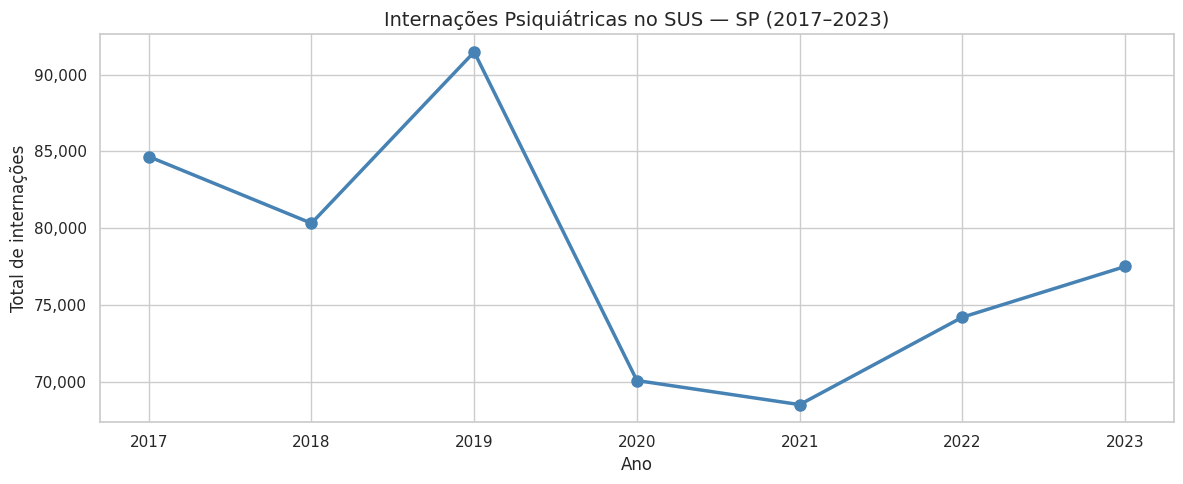

In [15]:
internacoes_ano = df.groupby('ANO').size().reset_index(name='total')

fig, ax = plt.subplots()

ax.plot(internacoes_ano['ANO'], internacoes_ano['total'], 
        marker='o', linewidth=2.5, markersize=8, color='steelblue')

ax.set_title('Internações Psiquiátricas no SUS — SP (2017–2023)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Total de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/01_evolucao_anual.png', dpi=150)
plt.show()

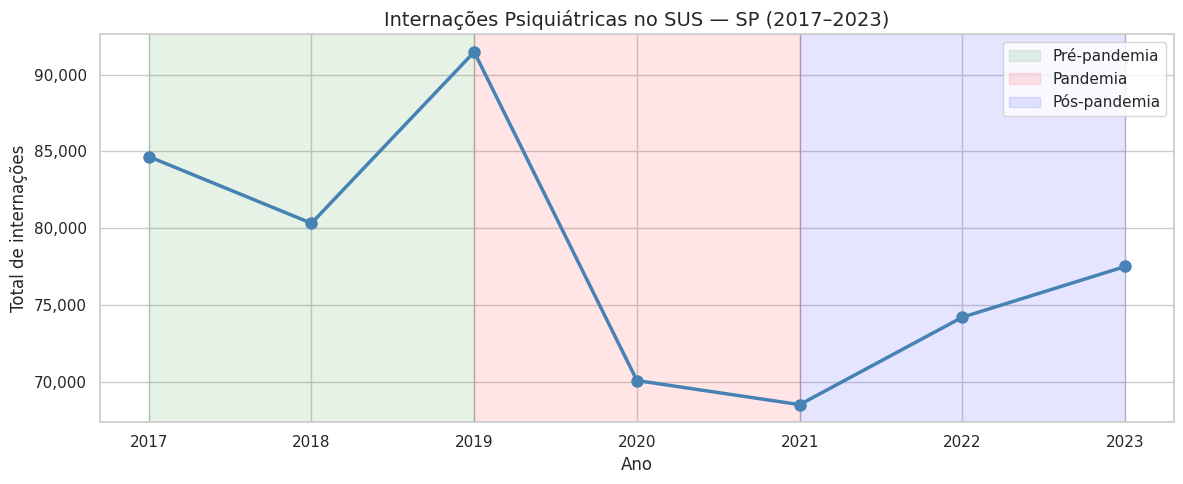

In [17]:
internacoes_ano = df.groupby('ANO').size().reset_index(name='total')

fig, ax = plt.subplots()

ax.plot(internacoes_ano['ANO'], internacoes_ano['total'],
        marker='o', linewidth=2.5, markersize=8, color='steelblue')

# linhas de período
ax.axvspan(2017, 2019, alpha=0.1, color='green', label='Pré-pandemia')
ax.axvspan(2019, 2021, alpha=0.1, color='red', label='Pandemia')
ax.axvspan(2021, 2023, alpha=0.1, color='blue', label='Pós-pandemia')

ax.set_title('Internações Psiquiátricas no SUS — SP (2017–2023)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Total de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/01_evolucao_anual.png', dpi=150)
plt.show()

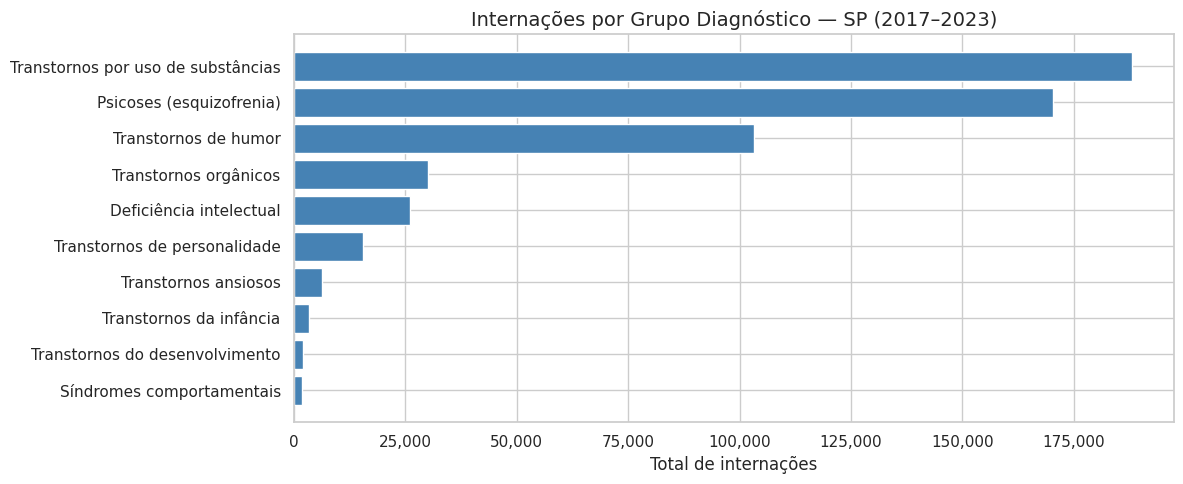

In [18]:
diag_total = df.groupby('GRUPO_DIAG').size().reset_index(name='total').sort_values('total')

fig, ax = plt.subplots()

ax.barh(diag_total['GRUPO_DIAG'], diag_total['total'], color='steelblue')

ax.set_title('Internações por Grupo Diagnóstico — SP (2017–2023)', fontsize=14)
ax.set_xlabel('Total de internações')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/02_por_diagnostico.png', dpi=150)
plt.show()

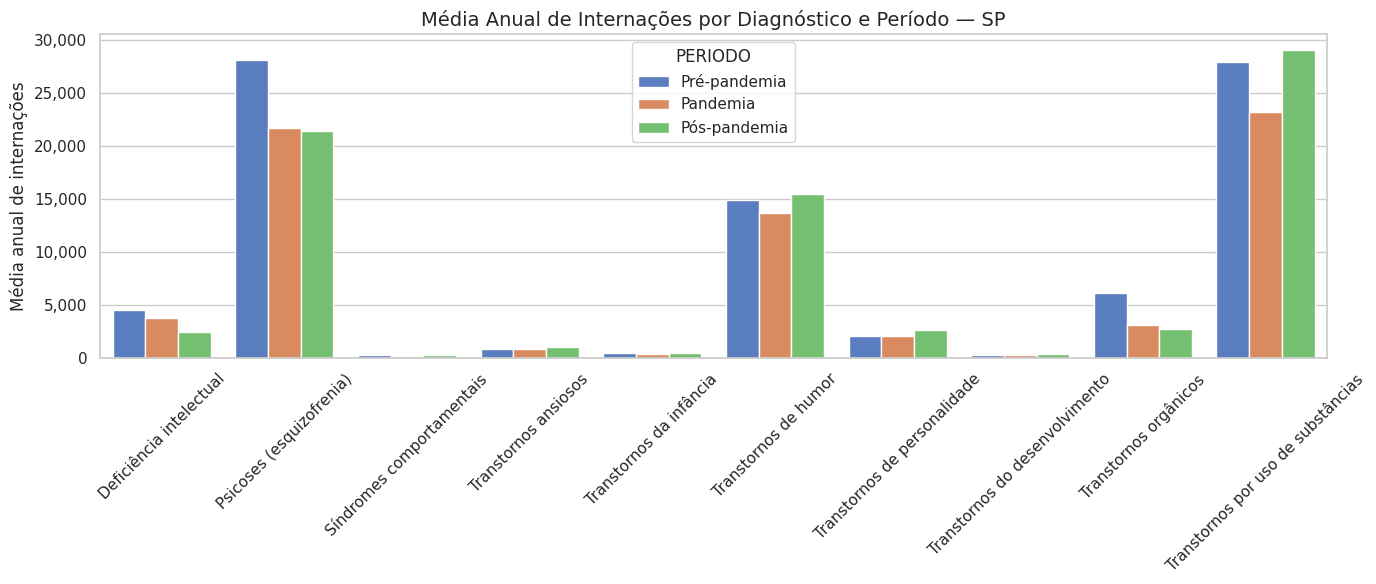

In [20]:
anos_por_periodo = {'Pré-pandemia': 3, 'Pandemia': 2, 'Pós-pandemia': 2}

diag_periodo['media_anual'] = diag_periodo.apply(
    lambda row: row['total'] / anos_por_periodo[row['PERIODO']], axis=1
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(data=diag_periodo, x='GRUPO_DIAG', y='media_anual',
            hue='PERIODO', ax=ax)

ax.set_title('Média Anual de Internações por Diagnóstico e Período — SP', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Média anual de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/03_diagnostico_por_periodo.png', dpi=150)
plt.show()


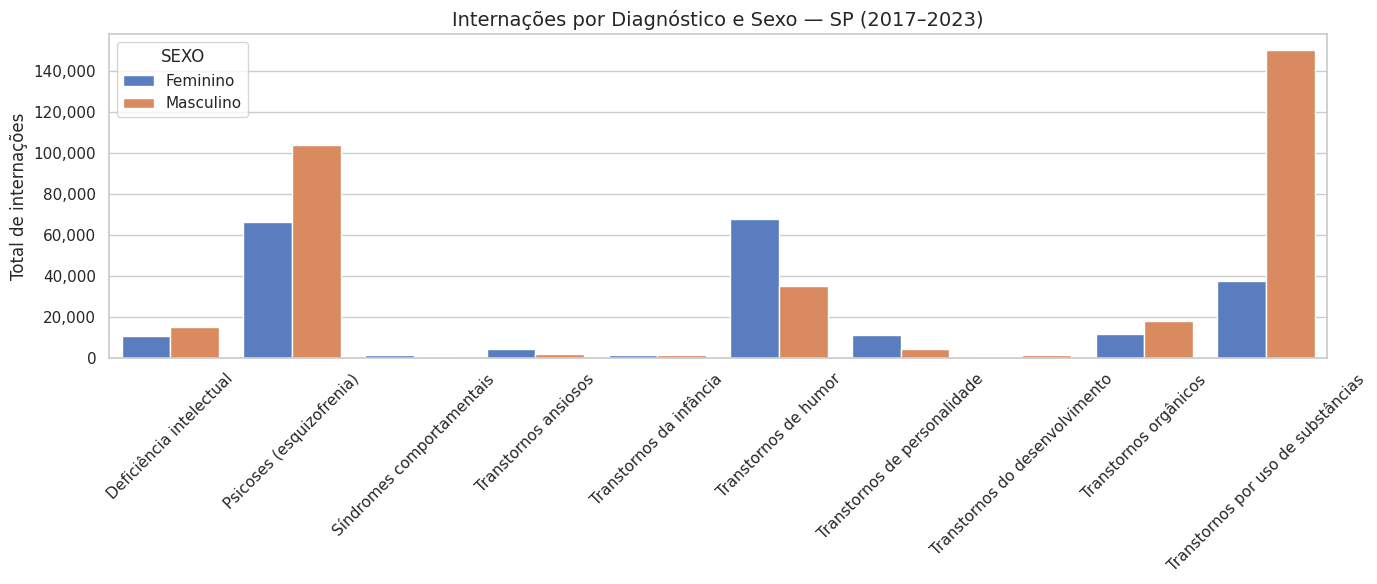

In [21]:
sexo_diag = df.groupby(['GRUPO_DIAG', 'SEXO']).size().reset_index(name='total')

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(data=sexo_diag, x='GRUPO_DIAG', y='total',
            hue='SEXO', ax=ax)

ax.set_title('Internações por Diagnóstico e Sexo — SP (2017–2023)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Total de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/04_por_sexo.png', dpi=150)
plt.show()

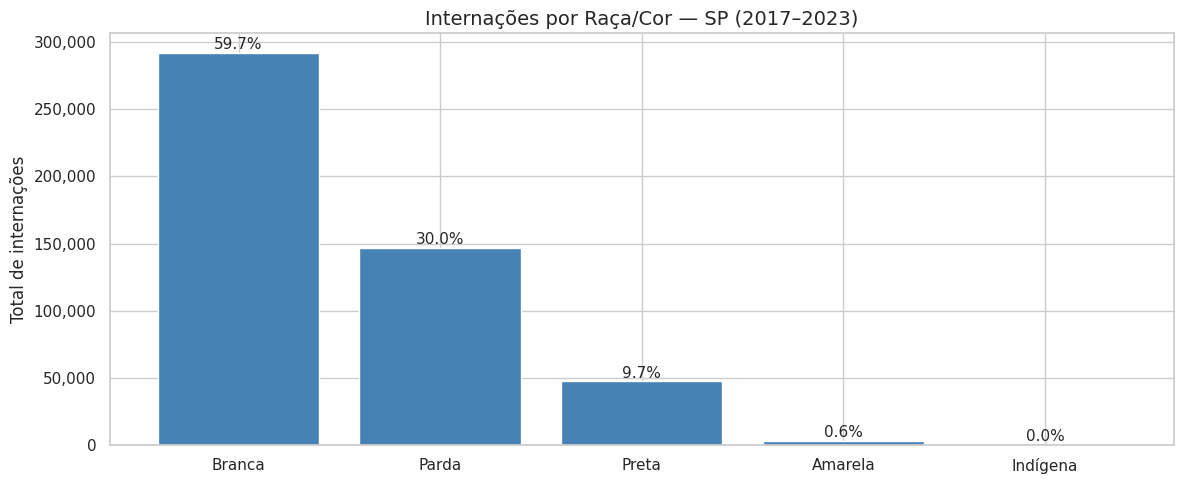

In [22]:
raca_total = df[df['RACA_COR'] != 'Ignorado'].groupby('RACA_COR').size().reset_index(name='total').sort_values('total', ascending=False)

# percentual
raca_total['pct'] = (raca_total['total'] / raca_total['total'].sum() * 100).round(1)

fig, ax = plt.subplots()

bars = ax.bar(raca_total['RACA_COR'], raca_total['total'], color='steelblue')

# adicionar percentual em cima de cada barra
for bar, pct in zip(bars, raca_total['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{pct}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Internações por Raça/Cor — SP (2017–2023)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Total de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/05_por_raca.png', dpi=150)
plt.show()

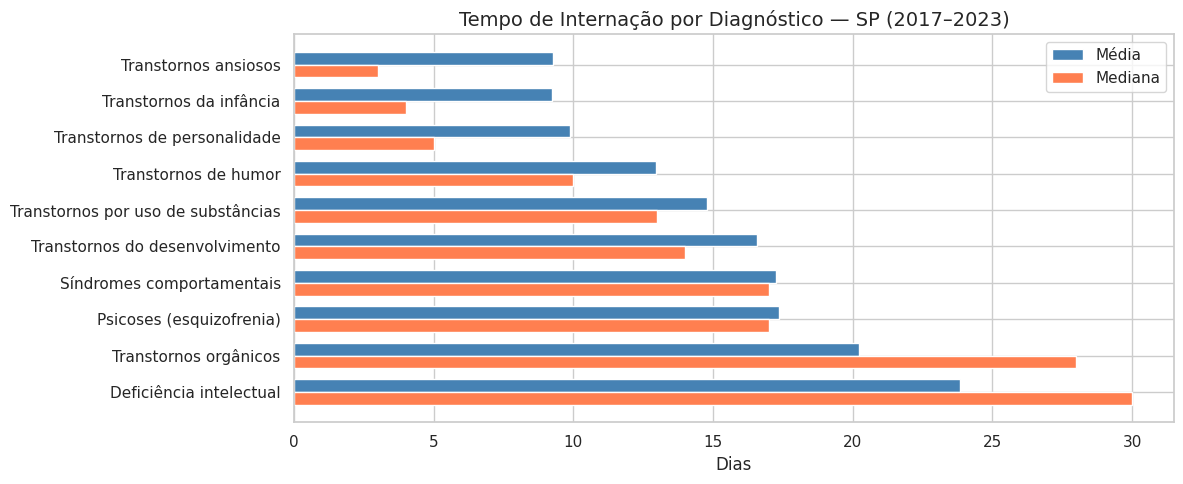

In [23]:
tempo_diag = df.groupby('GRUPO_DIAG')['DIAS_PERM'].agg(['mean', 'median']).reset_index()
tempo_diag.columns = ['GRUPO_DIAG', 'media', 'mediana']
tempo_diag = tempo_diag.sort_values('mediana', ascending=False)

fig, ax = plt.subplots()

x = range(len(tempo_diag))
width = 0.35

ax.barh([i + width/2 for i in x], tempo_diag['media'], width, label='Média', color='steelblue')
ax.barh([i - width/2 for i in x], tempo_diag['mediana'], width, label='Mediana', color='coral')

ax.set_yticks(x)
ax.set_yticklabels(tempo_diag['GRUPO_DIAG'])
ax.set_title('Tempo de Internação por Diagnóstico — SP (2017–2023)', fontsize=14)
ax.set_xlabel('Dias')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/06_tempo_internacao.png', dpi=150)
plt.show()